# EBM Semantic Stability Pipeline

**Goal:** Reduce output variance in language model generation using a trained Energy-Based Model (EBM) and Langevin dynamics decoding.

**Key ideas:**
1. A **learned MLP** (trained on STS-B + SNLI) scores semantic coherence — not a hand-crafted constraint.
2. A **cosine similarity drift penalty** anchors generation to the original prompt.
3. Primary metric: **output variance reduction** across repeated runs.

**Pipeline stations:**
1. Data preparation (STS-B + SNLI)
2. Training triples construction
3. EBM (MLP energy scorer) training via NCE
4. Langevin dynamics refinement in BERT embedding space
5. Re-ranking decode from refined vector
6. Evaluation — variance comparison over 50 prompts

In [2]:
# ── Cell 0: Install dependencies (Colab) ──
!pip install -q transformers datasets torch scikit-learn bert-score tqdm numpy pandas matplotlib accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00


In [3]:
# ── Cell 1: Imports & reproducibility ──
import os, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Create directories
os.makedirs("data", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)

Device: cuda


## Station 1 & 2 — Data Preparation

Load STS-B (positive pairs, score >= 4.0) and SNLI (contradiction pairs as hard negatives). Build training triples: `(anchor, positive, negative)`.

In [4]:
# ── Cell 2: Station 1 & 2 — Data preparation ──
from datasets import load_dataset

# ── Positive pairs from STS-B (score >= 4.0) ──
print("Loading STS-B...")
try:
    stsb = load_dataset("sentence-transformers/stsb", split="train")
except Exception as e:
    print(f"Error loading STS-B: {e}")
    raise

positive_pairs = []
for row in stsb:
    if row["score"] >= 4.0:
        positive_pairs.append((row["sentence1"], row["sentence2"]))
print(f"STS-B positive pairs (score >= 4.0): {len(positive_pairs)}")

# ── Hard negatives from SNLI contradictions ──
print("Loading SNLI...")
try:
    snli = load_dataset("snli", split="train")
except Exception as e:
    print(f"Error loading SNLI: {e}")
    raise

contradictions = [(x["premise"], x["hypothesis"]) for x in snli if x["label"] == 2]
contradictions = contradictions[:3000]
print(f"SNLI contradiction pairs: {len(contradictions)}")

# ── Build training triples ──
triples = []

# Type A: STS-B positive + shuffled negative
for s1, s2 in positive_pairs:
    words = s1.split()
    shuffled = words.copy()
    random.shuffle(shuffled)
    neg = " ".join(shuffled)
    triples.append({"anchor": s1, "positive": s2, "negative": neg})

# Type B: STS-B anchor + identity positive + SNLI contradiction negative
for i, (s1, s2) in enumerate(positive_pairs):
    if i >= len(contradictions):
        break
    _, contra_hyp = contradictions[i]
    triples.append({"anchor": s1, "positive": s1, "negative": contra_hyp})

# Type C: SNLI premise as anchor, premise as positive, hypothesis (contradiction) as negative
for premise, hypothesis in contradictions:
    words = premise.split()
    shuffled = words.copy()
    random.shuffle(shuffled)
    neg_shuffled = " ".join(shuffled)
    triples.append({"anchor": premise, "positive": premise, "negative": hypothesis})

random.shuffle(triples)
print(f"\nTotal training triples: {len(triples)}")
print(f"  From STS-B + shuffled negatives: {len(positive_pairs)}")
print(f"  From STS-B + SNLI hard negatives: {min(len(positive_pairs), len(contradictions))}")
print(f"  From SNLI contradictions: {len(contradictions)}")

# Save
with open("data/training_triples.json", "w") as f:
    json.dump(triples, f)
print(f"\nSaved to data/training_triples.json")

Loading STS-B...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/471k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/142k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/108k [00:00<?, ?B/s]

...

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/19.6M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/550152 [00:00<?, ? examples/s]

SNLI contradiction pairs: 3000

Total training triples: 3000
  From STS-B + shuffled negatives: 0
  From STS-B + SNLI hard negatives: 0
  From SNLI contradictions: 3000

Saved to data/training_triples.json


## Station 3 — Energy Model Definition & Training

BERT encoder (frozen) + 2-layer MLP energy scorer, trained with NCE margin loss.

In [5]:
# ── Cell 3: Station 3 — BERT encoder + EnergyMLP definition ──
from transformers import BertModel, BertTokenizer

# Load frozen BERT
print("Loading BERT-base-uncased...")
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.eval()
for param in bert_model.parameters():
    param.requires_grad = False
bert_model = bert_model.to(device)
print("BERT loaded and frozen.")


def encode_sentence(text, bert_model, tokenizer, device):
    """Encode a sentence to a 768d CLS vector using frozen BERT."""
    inputs = tokenizer(
        text, return_tensors="pt", max_length=128,
        padding="max_length", truncation=True
    ).to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze(0)  # CLS token, shape (768,)


def encode_batch(texts, bert_model, tokenizer, device, batch_size=32):
    """Encode a list of sentences to CLS vectors."""
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", max_length=128,
            padding="max_length", truncation=True
        ).to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
        all_vecs.append(outputs.last_hidden_state[:, 0, :])
    return torch.cat(all_vecs, dim=0)


class EnergyMLP(nn.Module):
    """2-layer MLP energy scorer. Input: |anchor - candidate| (768d) -> scalar energy."""
    def __init__(self, input_dim=768, hidden_dim=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


energy_mlp = EnergyMLP().to(device)
print(f"EnergyMLP parameters: {sum(p.numel() for p in energy_mlp.parameters()):,}")

Loading BERT-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded and frozen.
EnergyMLP parameters: 197,121


Loaded 3000 triples


Epoch 1/5:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 1 avg loss: 0.0460


Epoch 2/5:   0%|          | 0/94 [00:00<?, ?it/s]

  Step 100, Loss: 0.0000
Epoch 2 avg loss: 0.0026


...

  Step 200, Loss: 0.0000
Epoch 3 avg loss: 0.0018


Epoch 4/5:   0%|          | 0/94 [00:00<?, ?it/s]

  Step 300, Loss: 0.0017
Epoch 4 avg loss: 0.0013


Epoch 5/5:   0%|          | 0/94 [00:00<?, ?it/s]

  Step 400, Loss: 0.0000
Epoch 5 avg loss: 0.0011
Saved EnergyMLP to checkpoints/energy_mlp.pt


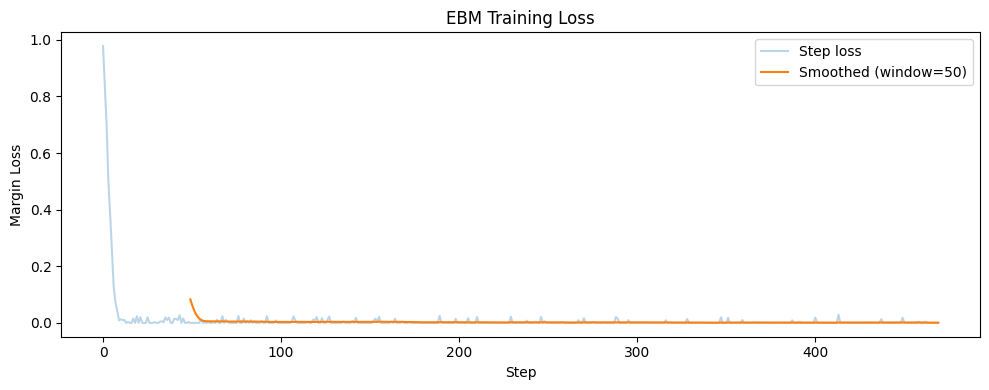

Saved results/training_loss.png


In [6]:
# ── Cell 4: Station 3 — NCE Training loop ──

class TriplesDataset(Dataset):
    def __init__(self, triples):
        self.triples = triples
    def __len__(self):
        return len(self.triples)
    def __getitem__(self, idx):
        return self.triples[idx]

# Load triples
with open("data/training_triples.json") as f:
    triples = json.load(f)
print(f"Loaded {len(triples)} triples")

dataset = TriplesDataset(triples)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Training setup
optimizer = torch.optim.Adam(energy_mlp.parameters(), lr=2e-4)
margin_loss = nn.MarginRankingLoss(margin=1.0)
energy_mlp.train()

NUM_EPOCHS = 5
step_losses = []
global_step = 0

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        anchors = batch["anchor"]
        positives = batch["positive"]
        negatives = batch["negative"]

        # Encode all sentences with frozen BERT
        anchor_vecs = encode_batch(anchors, bert_model, bert_tokenizer, device)
        pos_vecs = encode_batch(positives, bert_model, bert_tokenizer, device)
        neg_vecs = encode_batch(negatives, bert_model, bert_tokenizer, device)

        # Compute energy for positive and negative pairs
        pos_energy = energy_mlp(torch.abs(anchor_vecs - pos_vecs))
        neg_energy = energy_mlp(torch.abs(anchor_vecs - neg_vecs))

        # Target: positive energy should be LOWER than negative energy
        target = torch.ones(pos_energy.size(0), device=device)  # y=1 means x1 < x2
        # MarginRankingLoss: loss = max(0, -y*(x1-x2) + margin) = max(0, margin + x1 - x2) when y=1 means we want x1 < x2
        # But torch convention: y=1 means x1 should be ranked higher (larger)
        # We want neg_energy > pos_energy, so: x1=neg_energy, x2=pos_energy, y=1
        loss = margin_loss(neg_energy, pos_energy, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        step_losses.append(loss.item())
        global_step += 1

        if global_step % 100 == 0:
            print(f"  Step {global_step}, Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1} avg loss: {epoch_loss / len(dataloader):.4f}")

# Save model
energy_mlp.eval()
torch.save(energy_mlp.state_dict(), "checkpoints/energy_mlp.pt")
print("Saved EnergyMLP to checkpoints/energy_mlp.pt")

# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(step_losses, alpha=0.3, label="Step loss")
# Smoothed
window = 50
if len(step_losses) > window:
    smoothed = pd.Series(step_losses).rolling(window).mean()
    plt.plot(smoothed, label=f"Smoothed (window={window})")
plt.xlabel("Step")
plt.ylabel("Margin Loss")
plt.title("EBM Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/training_loss.png", dpi=150)
plt.show()
print("Saved results/training_loss.png")

## Station 4 & 5 — Language Model Loading + Langevin Decoding with Drift Penalty

Load Phi-3-mini (or TinyLlama fallback) in 4-bit quantization. Then implement the Langevin refinement loop in BERT embedding space + re-ranking decode.

In [7]:
# ── Cell 5: Load language model (Phi-3-mini or TinyLlama fallback) ──
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"

try:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    has_bnb = True
except Exception:
    has_bnb = False
    print("bitsandbytes not available, will load in float32")

try:
    print(f"Loading {MODEL_NAME}...")
    lm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if has_bnb:
        lm_model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
    else:
        lm_model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            torch_dtype=torch.float32,
            device_map="auto",
            trust_remote_code=True,
        )
except Exception as e:
    print(f"Failed to load Phi-3-mini ({e}), falling back to TinyLlama...")
    MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    lm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    lm_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto")

lm_model.eval()
for param in lm_model.parameters():
    param.requires_grad = False

# Set pad token if missing
if lm_tokenizer.pad_token is None:
    lm_tokenizer.pad_token = lm_tokenizer.eos_token

print(f"Loaded: {MODEL_NAME}")

Loading microsoft/Phi-3-mini-4k-instruct...


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-4k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [8]:
# ── Cell 6: Station 4 & 5 — Langevin decoding + re-ranking ──

def lm_generate_single(prompt, lm_model, lm_tokenizer, device,
                        do_sample=False, temperature=0.9, top_k=50, max_new_tokens=80):
    """Generate a single output from the LM using chat template."""
    messages = [{"role": "user", "content": prompt}]
    try:
        formatted = lm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        formatted = f"User: {prompt}\nAssistant:"
    inputs = lm_tokenizer(formatted, return_tensors="pt").to(device)
    with torch.no_grad():
        gen_kwargs = dict(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            pad_token_id=lm_tokenizer.pad_token_id,
        )
        if do_sample:
            gen_kwargs["temperature"] = temperature
            gen_kwargs["top_k"] = top_k
        output_ids = lm_model.generate(**gen_kwargs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return lm_tokenizer.decode(new_tokens, skip_special_tokens=True)


def rerank_candidates(refined_vec, prompt, lm_model, lm_tokenizer,
                      bert_model, bert_tokenizer, device, n_candidates=20):
    """Generate n_candidates from LM and return the one closest to refined_vec in BERT space."""
    candidates = []
    for _ in range(n_candidates):
        text = lm_generate_single(
            prompt, lm_model, lm_tokenizer, device,
            do_sample=True, temperature=0.9, top_k=50
        )
        if text.strip():
            candidates.append(text)
    if not candidates:
        return lm_generate_single(prompt, lm_model, lm_tokenizer, device, do_sample=False)

    candidate_vecs = encode_batch(candidates, bert_model, bert_tokenizer, device)
    sims = F.cosine_similarity(
        candidate_vecs, refined_vec.unsqueeze(0).expand_as(candidate_vecs)
    )
    best_idx = sims.argmax().item()
    return candidates[best_idx]


def ebm_generate(prompt, bert_model, bert_tokenizer, lm_model, lm_tokenizer,
                 energy_mlp, device, n_steps=20, alpha=0.5, step_size=0.1,
                 noise_scale=0.01, n_candidates=20):
    """
    Full EBM-guided generation:
    1. Encode prompt with BERT
    2. Generate initial draft from LM, encode with BERT
    3. Refine draft vector via Langevin dynamics (EBM energy + drift penalty)
    4. Re-rank LM candidates against refined vector
    """
    # Step 1: Encode prompt
    prompt_vec = encode_sentence(prompt, bert_model, bert_tokenizer, device).detach()

    # Step 2: Initial draft from LM
    initial_text = lm_generate_single(prompt, lm_model, lm_tokenizer, device, do_sample=False)
    current_draft = encode_sentence(initial_text, bert_model, bert_tokenizer, device).detach()

    # Step 3: Langevin refinement
    energy_mlp.eval()
    for step in range(n_steps):
        current_draft = current_draft.detach().requires_grad_(True)

        # EBM energy
        ebm_energy = energy_mlp(torch.abs(prompt_vec - current_draft))

        # Drift penalty
        cosine_sim = F.cosine_similarity(
            current_draft.unsqueeze(0), prompt_vec.unsqueeze(0)
        )
        drift_penalty = 1.0 - cosine_sim

        # Total energy
        total_energy = ebm_energy + alpha * drift_penalty.squeeze()
        total_energy.backward()

        grad = current_draft.grad.detach()
        current_draft = current_draft.detach() - step_size * grad
        current_draft = current_draft + noise_scale * torch.randn_like(current_draft)
        current_draft = current_draft.detach()

    # Step 4: Re-rank candidates
    result = rerank_candidates(
        current_draft, prompt, lm_model, lm_tokenizer,
        bert_model, bert_tokenizer, device, n_candidates=n_candidates
    )
    return result


# Quick smoke test
print("Smoke test: ebm_generate...")
test_out = ebm_generate(
    "What is photosynthesis?",
    bert_model, bert_tokenizer, lm_model, lm_tokenizer,
    energy_mlp, device, n_steps=5, n_candidates=5
)
print(f"Output: {test_out[:200]}...")
print("Smoke test passed!")

Smoke test: ebm_generate...
Output: Photosynthesis is a process by which plants, algae, and certain bacteria convert sunlight, water, carbon dioxide, and nutrients into organic matter, such as glucose (a simple sugar) and oxygen. During...
Smoke test passed!


## Station 6 — Evaluation & Experiment

Run 5 generations per prompt x 10 prompts for both baseline and EBM. Compute semantic variance and BERTScore.

In [9]:
# ── Cell 7: Station 6 — Evaluation (fast ~5 min version) ──
from bert_score import score as bert_score_fn

PROMPTS = [
    "What is photosynthesis?",
    "Explain how gravity works.",
    "What is machine learning?",
    "How do vaccines work?",
    "What is quantum mechanics?",
    "How do airplanes fly?",
    "What is entropy?",
    "How does CRISPR work?",
    "What is game theory?",
    "Explain what recursion is in programming.",
]

N_RUNS = 5
N_CANDIDATES = 8
N_LANGEVIN = 10

def compute_semantic_variance(texts, bert_model, bert_tokenizer, device):
    vecs = encode_batch(texts, bert_model, bert_tokenizer, device).cpu().numpy()
    sim_matrix = sk_cosine(vecs)
    n = len(texts)
    upper = sim_matrix[np.triu_indices(n, k=1)]
    variance = 1.0 - upper.mean()
    return variance

def compute_bertscore_avg(outputs, prompt):
    refs = [prompt] * len(outputs)
    P, R, F1 = bert_score_fn(outputs, refs, lang="en", verbose=False)
    return F1.mean().item()

print(f"Running evaluation: {len(PROMPTS)} prompts × {N_RUNS} runs × 2 systems")
print(f"  (Langevin steps={N_LANGEVIN}, candidates={N_CANDIDATES})\n")

results = []

for i, prompt in enumerate(tqdm(PROMPTS, desc="Prompts")):
    baseline_outputs = []
    for _ in range(N_RUNS):
        text = lm_generate_single(
            prompt, lm_model, lm_tokenizer, device,
            do_sample=True, temperature=0.9, top_k=50
        )
        baseline_outputs.append(text if text.strip() else "N/A")

    baseline_var = compute_semantic_variance(baseline_outputs, bert_model, bert_tokenizer, device)
    baseline_bs = compute_bertscore_avg(baseline_outputs, prompt)

    ebm_outputs = []
    for _ in range(N_RUNS):
        text = ebm_generate(
            prompt, bert_model, bert_tokenizer, lm_model, lm_tokenizer,
            energy_mlp, device, n_steps=N_LANGEVIN, alpha=0.5,
            n_candidates=N_CANDIDATES
        )
        ebm_outputs.append(text if text.strip() else "N/A")

    ebm_var = compute_semantic_variance(ebm_outputs, bert_model, bert_tokenizer, device)
    ebm_bs = compute_bertscore_avg(ebm_outputs, prompt)

    results.append({
        "prompt": prompt,
        "baseline_var": baseline_var,
        "ebm_var": ebm_var,
        "baseline_bertscore": baseline_bs,
        "ebm_bertscore": ebm_bs,
    })
    print(f"  [{i+1}/{len(PROMPTS)}] B_var={baseline_var:.4f}  E_var={ebm_var:.4f}")

print("\nEvaluation complete!")


Running evaluation: 10 prompts × 5 runs × 2 systems
  (Langevin steps=10, candidates=8)



Prompts:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [10/10] B_var=0.1436  E_var=0.1257

Evaluation complete!


Prompt                                           B_Var    E_Var     B_BS     E_BS
----------------------------------------------------------------------------------
What is photosynthesis?                         0.1031   0.0465   0.8571   0.8561
Explain how gravity works.                      0.1687   0.1007   0.8547   0.8562
What is machine learning?                       0.0958   0.0666   0.8590   0.8523
How do vaccines work?                           0.1681   0.0772   0.8551   0.8531
What is quantum mechanics?                      0.0932   0.0707   0.8580   0.8590
How do airplanes fly?                           0.1695   0.1098   0.8574   0.8647
What is entropy?                                0.1390   0.0705   0.8472   0.8463
How does CRISPR work?                           0.1663   0.1663   0.8410   0.8423
What is game theory?                            0.0896   0.0550   0.8576   0.8620
Explain what recursion is in programming.       0.1436   0.1257   0.8569   0.8584

Saved results/

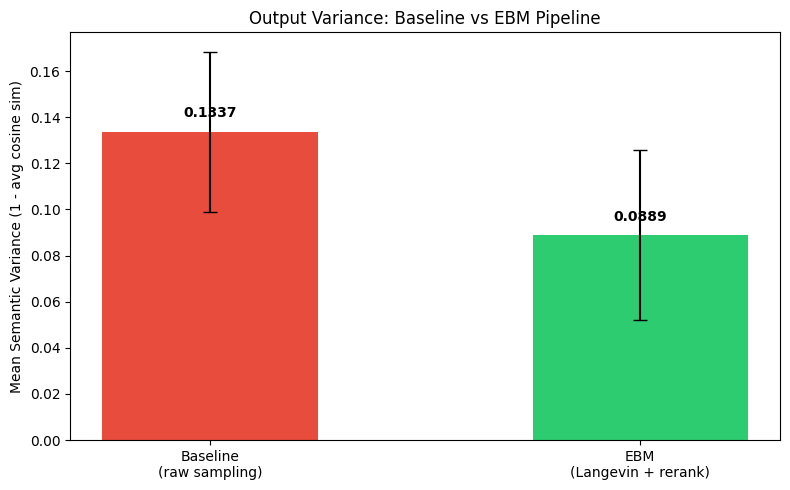

Saved results/variance_comparison.png

SUMMARY
Mean baseline variance:   0.1337
Mean EBM variance:        0.0889
Variance reduction:       33.5%
Mean baseline BERTScore:  0.8544
Mean EBM BERTScore:       0.8550

Top 5 prompts by variance reduction:
  How do vaccines work?                                Δ = 0.0909
  What is entropy?                                     Δ = 0.0685
  Explain how gravity works.                           Δ = 0.0679
  How do airplanes fly?                                Δ = 0.0597
  What is photosynthesis?                              Δ = 0.0566

Bottom 5 prompts (least improvement):
  How does CRISPR work?                                Δ = -0.0001
  Explain what recursion is in programming.            Δ = 0.0179
  What is quantum mechanics?                           Δ = 0.0225
  What is machine learning?                            Δ = 0.0293
  What is game theory?                                 Δ = 0.0346


In [10]:
# ── Cell 8: Results table, CSV, plots, and summary ──

df = pd.DataFrame(results)

# ── Print results table ──
print(f"{'Prompt':<45} {'B_Var':>8} {'E_Var':>8} {'B_BS':>8} {'E_BS':>8}")
print("-" * 82)
for _, row in df.iterrows():
    prompt_short = row["prompt"][:42] + "..." if len(row["prompt"]) > 42 else row["prompt"]
    print(f"{prompt_short:<45} {row['baseline_var']:>8.4f} {row['ebm_var']:>8.4f} "
          f"{row['baseline_bertscore']:>8.4f} {row['ebm_bertscore']:>8.4f}")

# ── Save CSV ──
df.to_csv("results/variance_table.csv", index=False)
print(f"\nSaved results/variance_table.csv")

# ── Bar chart: variance comparison ──
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
means = [df["baseline_var"].mean(), df["ebm_var"].mean()]
stds = [df["baseline_var"].std(), df["ebm_var"].std()]
bars = ax.bar(x, means, yerr=stds, capsize=5, color=["#e74c3c", "#2ecc71"], width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(["Baseline\n(raw sampling)", "EBM\n(Langevin + rerank)"])
ax.set_ylabel("Mean Semantic Variance (1 - avg cosine sim)")
ax.set_title("Output Variance: Baseline vs EBM Pipeline")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{m:.4f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("results/variance_comparison.png", dpi=150)
plt.show()
print("Saved results/variance_comparison.png")

# ── Summary statistics ──
mean_b_var = df["baseline_var"].mean()
mean_e_var = df["ebm_var"].mean()
reduction_pct = (mean_b_var - mean_e_var) / mean_b_var * 100 if mean_b_var > 0 else 0

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Mean baseline variance:   {mean_b_var:.4f}")
print(f"Mean EBM variance:        {mean_e_var:.4f}")
print(f"Variance reduction:       {reduction_pct:.1f}%")
print(f"Mean baseline BERTScore:  {df['baseline_bertscore'].mean():.4f}")
print(f"Mean EBM BERTScore:       {df['ebm_bertscore'].mean():.4f}")

# Top improvements
df["improvement"] = df["baseline_var"] - df["ebm_var"]
top5 = df.nlargest(5, "improvement")
print(f"\nTop 5 prompts by variance reduction:")
for _, row in top5.iterrows():
    print(f"  {row['prompt'][:50]:<52} Δ = {row['improvement']:.4f}")

# Worst
worst5 = df.nsmallest(5, "improvement")
print(f"\nBottom 5 prompts (least improvement):")
for _, row in worst5.iterrows():
    print(f"  {row['prompt'][:50]:<52} Δ = {row['improvement']:.4f}")

## Hyperparameters & COLD Decoding Comparison

### Tunable hyperparameters

| Parameter | Default | Controls |
|-----------|---------|----------|
| `step_size` | 0.1 | Langevin step magnitude — larger = faster convergence but risk overshooting |
| `alpha` | 0.5 | Weight of cosine drift penalty vs EBM energy — higher = more anchored to prompt |
| `noise_scale` | 0.01 | Langevin noise injection — higher = more exploration, prevents mode collapse |
| `n_steps` | 20 | Number of Langevin iterations — more steps = more refinement but slower |
| `n_candidates` | 20 | Re-ranking pool size — more = better selection but slower |
| `temperature` | 0.9 | LM sampling temperature for candidate generation |
| `margin` | 1.0 | NCE training margin — larger = stricter separation between positive/negative energies |

### Comparison with COLD Decoding (Qin et al., NeurIPS 2022)

**Similarities:**
- Both operate in a continuous latent space and use gradient-based updates (Langevin dynamics) to refine text representations
- Both use a frozen language model as the backbone — neither finetunes the LM
- Both add noise during the optimization loop (stochastic Langevin step)
- The iterative decode-then-refine loop structure is shared

**Key differences:**
| Aspect | COLD Decoding | This work |
|--------|--------------|-----------|
| Energy function | Hand-crafted constraints (fluency, keyword, length) | **Learned MLP** trained on STS-B + SNLI semantic similarity data |
| Optimization space | Token logit space (soft tokens) | BERT CLS embedding space (768d semantic vectors) |
| Decoding | Direct projection from soft tokens → hard tokens via argmax | **Re-ranking**: generate diverse candidates from LM, select closest to refined vector |
| Drift control | Fluency constraint via LM log-prob | **Cosine similarity drift penalty** anchoring to prompt embedding |
| Primary metric | Constraint satisfaction (keyword inclusion, sentiment match) | **Output variance reduction** across repeated runs |
| Training required | None (hand-crafted) | NCE training of the energy MLP on semantic similarity data |